In [134]:
import pandas as pd

In [135]:
df = pd.read_csv('expense.csv')


In [136]:
df

,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00
5,08-15-2026,Transportation,Uber,16.00
6,08-20-2026,Food,Grocery,70.00
7,08-02-2026,Shopping,Clothes,100.21
8,08-17-2026,School,School supplies,50.00
9,08-17-2026,Transportation,Bus pass,50.45


In [137]:
df.head()


,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00


In [138]:
df.tail()

,Date,Category,Description,Amount
42,03-10-2027,Food,Grocery,100.00
43,03-17-2027,Entertainment,Cineplex,20.00
44,02-26-2027,Transportation,Uber,30.00
45,02-20-2027,Shopping,Shoes,70.00
46,03-05-2027,Entertainment,Prime Video Movie Rent,24.99


In [139]:
df.columns

Index(['Date', 'Category', 'Description', 'Amount'], dtype='str')

In [140]:
df['Amount']

0      24.78
1      25.41
2      16.00
3      24.54
4      55.00
5      16.00
6      70.00
7     100.21
8      50.00
9      50.45
10    600.00
11    600.00
12     60.00
13    100.59
14     50.68
15     45.00
16    100.00
17     70.00
18     50.00
19     30.00
20     25.00
21     38.79
22    600.00
23     20.83
24     10.49
25     90.00
26      5.59
27    600.00
28    600.00
29    200.00
30    200.00
31     50.00
32     40.00
33    350.00
34    150.00
35     40.00
36    100.00
37     80.00
38    600.00
39    600.00
40     60.00
41     70.00
42    100.00
43     20.00
44     30.00
45     70.00
46     24.99
Name: Amount, dtype: float64

In [141]:
df['Amount'].sum()

np.float64(6914.35)

In [142]:
df['Amount'].mean()

np.float64(147.11382978723404)

In [143]:
df['Amount'].min()

np.float64(5.59)

In [144]:
df['Amount'].max()

np.float64(600.0)

In [145]:
category_totals = df.groupby('Category')['Amount'].sum()

In [146]:
category_totals

Category
Entertainment      230.53
Food               701.00
Rent              4200.00
School             185.59
Shopping           694.68
Transportation     502.55
Utilities          400.00
Name: Amount, dtype: float64

In [147]:
df.groupby('Category').size()

Category
Entertainment     6
Food              8
Rent              7
School            4
Shopping          8
Transportation    7
Utilities         7
dtype: int64

In [148]:
import matplotlib.pyplot as plt

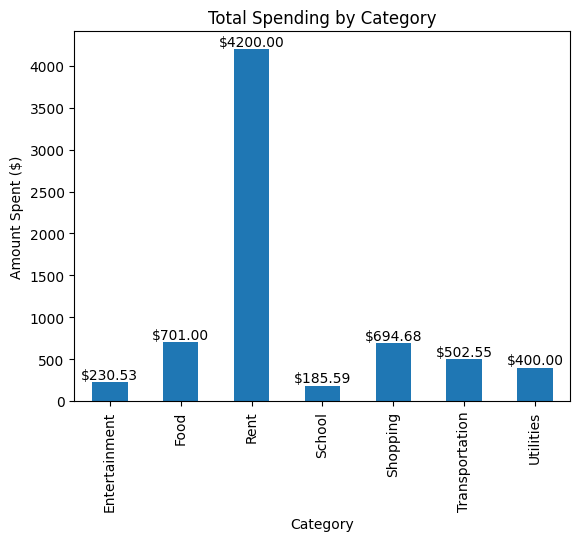

In [149]:
ax = category_totals.plot(kind='bar')

plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount Spent ($)')

for i, value in enumerate(category_totals):
    ax.text(i, value, f'${value:.2f}', ha='center', va='bottom')

plt.show()

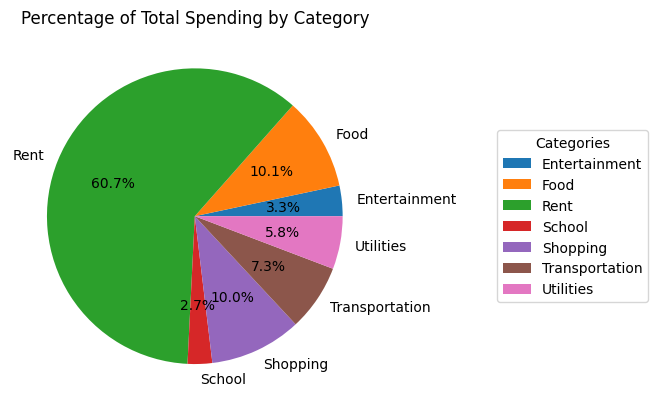

In [150]:
category_totals.plot(kind='pie', autopct='%1.1f%%')

plt.title('Percentage of Total Spending by Category')
plt.ylabel('')

plt.legend(
           title='Categories',
           bbox_to_anchor=(1.3,0.5),
           loc='center left')

plt.show()

In [151]:
df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [152]:
df['Date'] = pd.to_datetime(df['Date'])

In [153]:
df['Date'].dtype

dtype('<M8[us]')

In [154]:
daily_spending = df.groupby('Date')['Amount'].sum()

In [155]:
daily_spending

Date
2026-08-02    100.21
2026-08-03     16.00
2026-08-04     24.54
2026-08-07     24.78
2026-08-10     55.00
2026-08-15     41.41
2026-08-17    100.45
2026-08-20     70.00
2026-09-01    600.00
2026-09-06     90.00
2026-09-08    100.59
2026-09-10     50.00
2026-09-15     50.68
2026-10-02    600.00
2026-10-04     10.49
2026-10-05     70.00
2026-10-16     30.00
2026-10-23     25.00
2026-10-24     38.79
2026-10-25      5.59
2026-11-01    660.00
2026-11-08     45.00
2026-11-25     20.83
2026-11-28    100.00
2026-12-01    600.00
2026-12-16    200.00
2026-12-19     50.00
2026-12-24    200.00
2026-12-25    100.00
2027-01-02    600.00
2027-01-07    150.00
2027-01-09     40.00
2027-01-19     40.00
2027-01-20    350.00
2027-02-01    600.00
2027-02-09     80.00
2027-02-19     60.00
2027-02-20     70.00
2027-02-26     30.00
2027-03-01    600.00
2027-03-05     24.99
2027-03-10    100.00
2027-03-17     20.00
2027-03-19     70.00
Name: Amount, dtype: float64

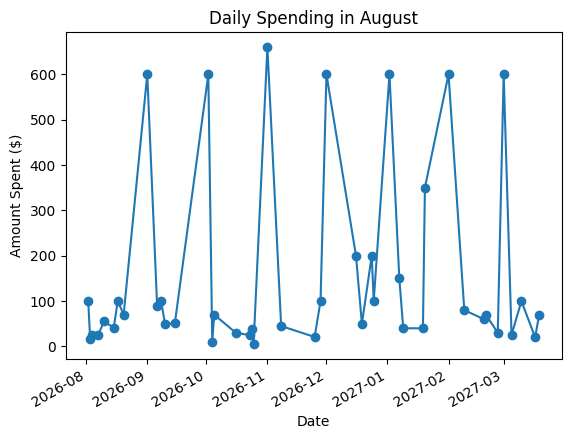

In [156]:
daily_spending.plot(kind='line', marker='o')

plt.title('Daily Spending in August')
plt.xlabel('Date')
plt.ylabel('Amount Spent ($)' )

plt.show()

In [157]:
daily_spending.max()

np.float64(660.0)

In [158]:
daily_spending.loc[daily_spending.idxmax()]

np.float64(660.0)

In [159]:
df['Month'] = df['Date'].dt.month

In [160]:
df.head()

,Date,Category,Description,Amount,Month
0,2026-08-07,Transportation,Lyft,24.78,8
1,2026-08-15,Food,Ubereats,25.41,8
2,2026-08-03,Entertainment,Cineplex,16.00,8
3,2026-08-04,Entertainment,Netflix subscription,24.54,8
4,2026-08-10,Shopping,Personal care,55.00,8


In [161]:
monthly_totals = df.groupby('Month')['Amount'].sum()

In [162]:
month_order = [8,9,10,11,12,1,2,3,4,5,6]

monthly_totals = monthly_totals.reindex(month_order)

monthly_totals

Month
8      432.39
9      891.27
10     779.87
11     825.83
12    1150.00
1     1180.00
2      840.00
3      814.99
4         NaN
5         NaN
6         NaN
Name: Amount, dtype: float64

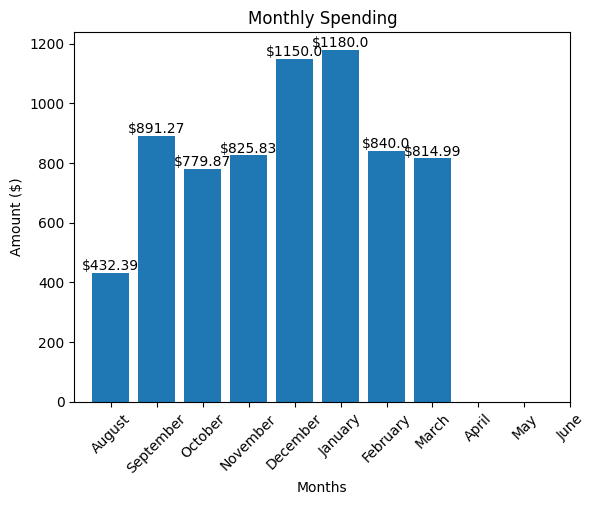

In [163]:
bars = plt.bar(range(len(monthly_totals)), monthly_totals.values)
labels = []
for amount in monthly_totals.values:
     label = f'${amount}'
     labels.append(label)

plt.bar_label(bars,labels)

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(range(len(monthly_totals)),['August','September','October','November','December','January','February','March','April','May','June'],rotation=45)

plt.show()

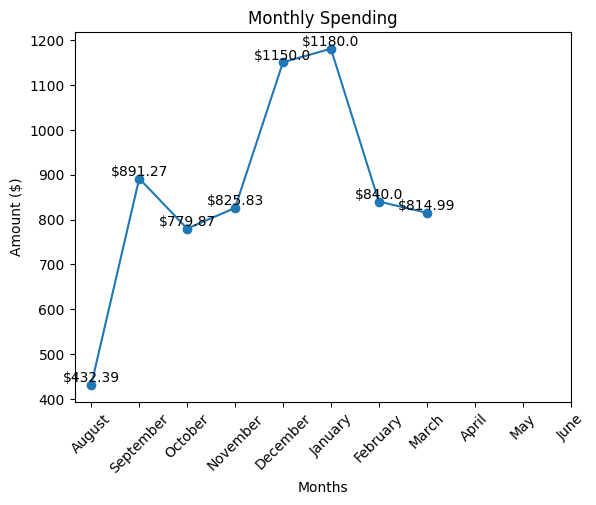

In [164]:
plt.plot(range(len(monthly_totals)),monthly_totals.values,marker='o')

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(range(len(monthly_totals)), ['August','September','October','November','December','January','February','March','April','May','June'],rotation=45)

for month,amount,label in zip(range(len(monthly_totals)),monthly_totals.values,labels):
    plt.text(month,amount,label,ha='center',va='bottom')
plt.show()

In [165]:
print(df.head())
print(df.info())

        Date        Category           Description  Amount  Month
0 2026-08-07  Transportation                  Lyft   24.78      8
1 2026-08-15            Food              Ubereats   25.41      8
2 2026-08-03   Entertainment              Cineplex   16.00      8
3 2026-08-04   Entertainment  Netflix subscription   24.54      8
4 2026-08-10        Shopping         Personal care   55.00      8
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         47 non-null     datetime64[us]
 1   Category     47 non-null     str           
 2   Description  47 non-null     str           
 3   Amount       47 non-null     float64       
 4   Month        47 non-null     int32         
dtypes: datetime64[us](1), float64(1), int32(1), str(2)
memory usage: 1.8 KB
None


In [166]:
print(df.columns)

Index(['Date', 'Category', 'Description', 'Amount', 'Month'], dtype='str')


In [167]:
month_order = [8,9,10,11,12,1,2,3,4,5,6]

monthly_data = df.groupby('Month')['Amount'].sum().reset_index()

monthly_data = monthly_data.set_index('Month').loc[month_order].reset_index()

print(monthly_data)

KeyError: '[4, 5, 6] not in index'

In [ ]:
monthly_data['Previous_Month'] = monthly_data['Amount'].shift(1)

In [ ]:
monthly_data = monthly_data.dropna()

monthly_data

,Month,Amount,Previous_Month
1,9,891.27,432.39
2,10,779.87,891.27
3,11,825.83,779.87
4,12,1150.00,825.83
5,1,1180.00,1150.00
6,2,840.00,1180.00
7,3,814.99,840.00


In [ ]:
x = monthly_data[['Previous_Month']]
y = monthly_data['Amount']

print(x)
print(y)

   Previous_Month
1          432.39
2          891.27
3          779.87
4          825.83
5         1150.00
6         1180.00
7          840.00
1     891.27
2     779.87
3     825.83
4    1150.00
5    1180.00
6     840.00
7     814.99
Name: Amount, dtype: float64


In [ ]:
x_train = x.iloc[:5]
x_test = x.iloc[5:]
y_train = y.iloc[:5]
y_test = y.iloc[5:]

print(x_train)
print(x_test)
print(y_train)
print(y_test)

   Previous_Month
1          432.39
2          891.27
3          779.87
4          825.83
5         1150.00
   Previous_Month
6          1180.0
7           840.0
1     891.27
2     779.87
3     825.83
4    1150.00
5    1180.00
Name: Amount, dtype: float64
6    840.00
7    814.99
Name: Amount, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print(model.coef_)
print(model.intercept_)

[0.34993528]
679.8916012652569


In [ ]:
predictions = model.predict(x_test)

print(predictions)

[1092.81523452  973.83723849]


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,predictions)

print(mae)

205.83123650471896
